In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
DATA_PATH = "D:/Data_D/TMU/MRP/1.0.Dataset/Crime_Socio_Economic_Weather_Mobility.csv"

In [3]:
SAVE_DIR = "saved_charts"
DPI = 300
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
_chart_idx = [0]

def save(name):

    _chart_idx[0] += 1

    file_name = str(_chart_idx[0]).zfill(2) + "_" + name + ".png"
    path = os.path.join(SAVE_DIR, file_name)

    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    plt.show()
    plt.close()

    print("Saved:", path)

In [5]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date', 'date'])

# Clean up mobility numeric columns (stored as strings with commas)
for col in ['bus', 'rail_boardings', 'total_rides']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '').str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Rows:', len(df))
print('Columns:', df.shape[1])

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

day_labels = [
    'Mon', 'Tue', 'Wed', 'Thu',
    'Fri', 'Sat', 'Sun'
]


Rows: 7970658
Columns: 39


# 1. Crime Trend Over Time

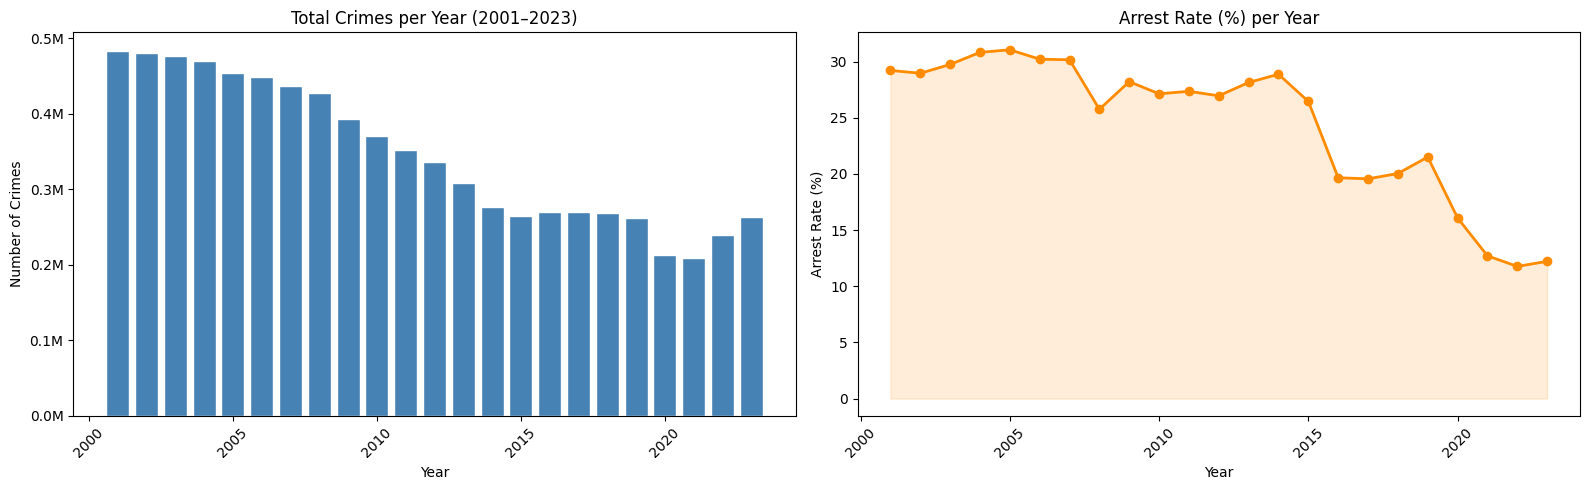

Saved: saved_charts\01_crimes_and_arrest_rate_per_year.png


In [6]:
yearly = df.groupby('year').agg(total_crimes=('ID', 'count'), total_arrests=('Arrest', 'sum')).reset_index()
yearly['arrest_rate'] = (yearly['total_arrests'] / yearly['total_crimes'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(yearly['year'], yearly['total_crimes'], color='steelblue', edgecolor='white')
axes[0].set_title('Total Crimes per Year (2001–2023)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Crimes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(yearly['year'], yearly['arrest_rate'], marker='o', color='darkorange', linewidth=2)
axes[1].fill_between(yearly['year'], yearly['arrest_rate'], color='darkorange', alpha=0.15)
axes[1].set_title('Arrest Rate (%) per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Arrest Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

save("crimes_and_arrest_rate_per_year")

# 2. Total Monthly crimes 

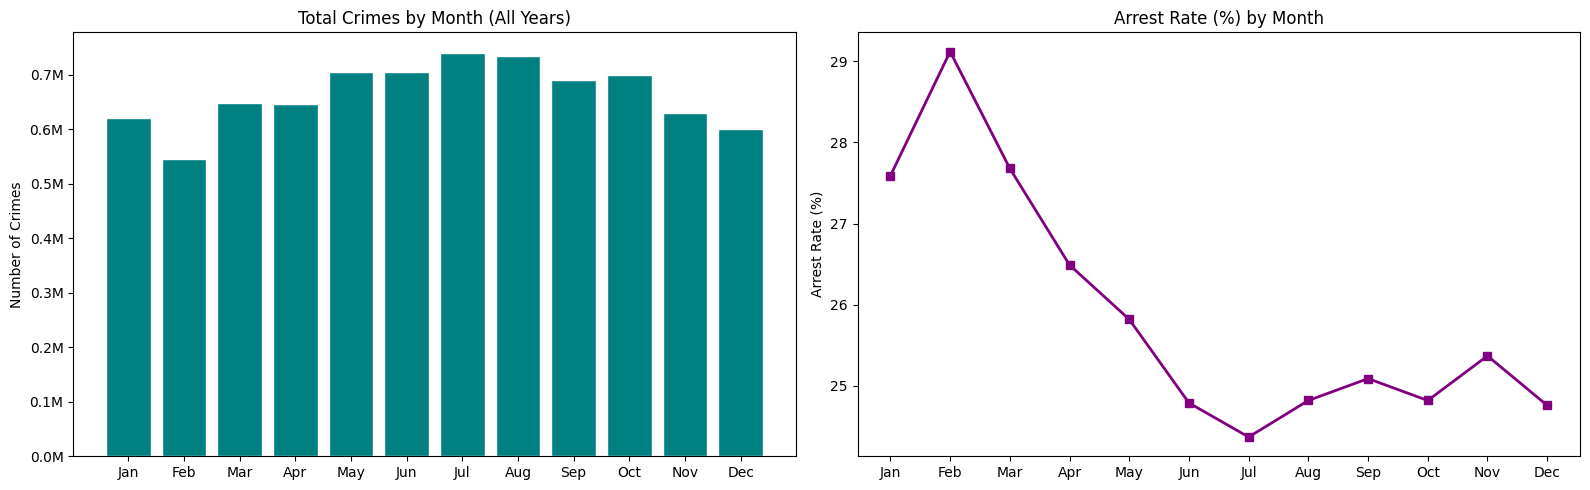

Saved: saved_charts\02_crimes_and_arrest_rate_by_month.png


In [7]:
monthly = df.groupby('month').agg(total_crimes=('ID', 'count'), total_arrests=('Arrest', 'sum')).reset_index()
monthly['arrest_rate'] = (monthly['total_arrests'] / monthly['total_crimes'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(monthly['month'], monthly['total_crimes'], color='teal', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Total Crimes by Month (All Years)')
axes[0].set_ylabel('Number of Crimes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

axes[1].plot(monthly['month'], monthly['arrest_rate'], marker='s', color='purple', linewidth=2)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Arrest Rate (%) by Month')
axes[1].set_ylabel('Arrest Rate (%)')

plt.tight_layout()

save("crimes_and_arrest_rate_by_month")

# 3. Top 15 Crime types

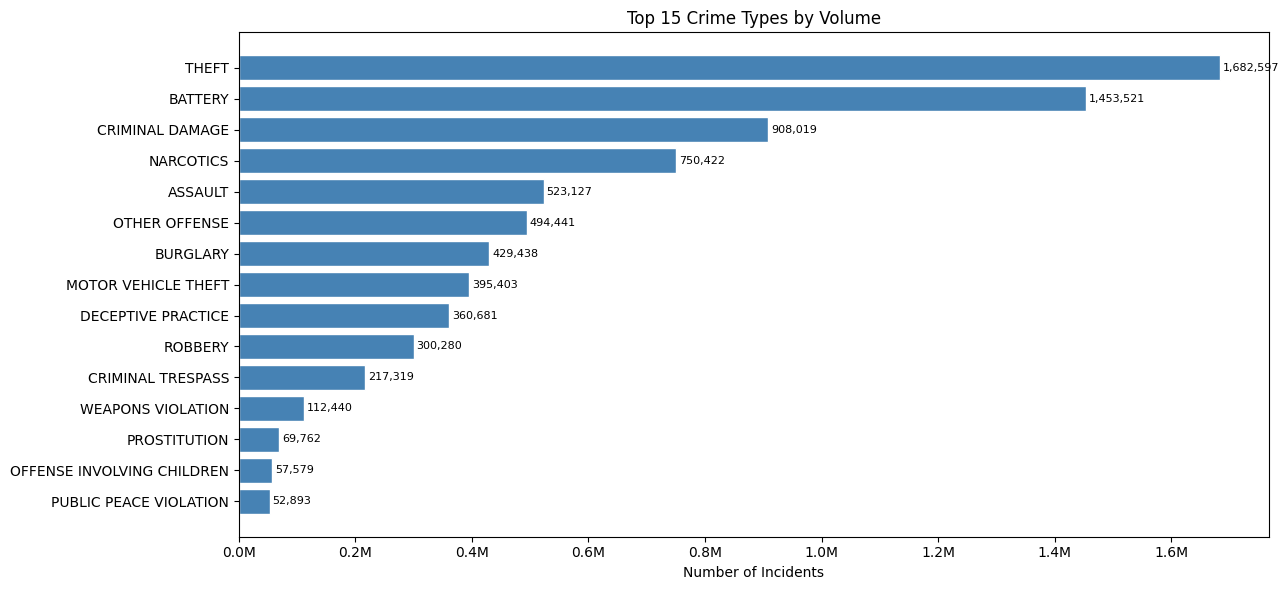

Saved: saved_charts\03_top15_crime_types_by_volume.png


In [8]:
top15 = df['Primary Type'].value_counts().head(15)

plt.figure(figsize=(13, 6))

bars = plt.barh(top15.index[::-1], top15.values[::-1], color='steelblue', edgecolor='white')

plt.xlabel('Number of Incidents')
plt.title('Top 15 Crime Types by Volume')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

for bar, value in zip(bars, top15.values[::-1]):
    plt.text(value + 5000, bar.get_y() + bar.get_height() / 2, format(value, ','), va='center', fontsize=8)

plt.tight_layout()

save("top15_crime_types_by_volume")

# 4. Arresr rate by crime type

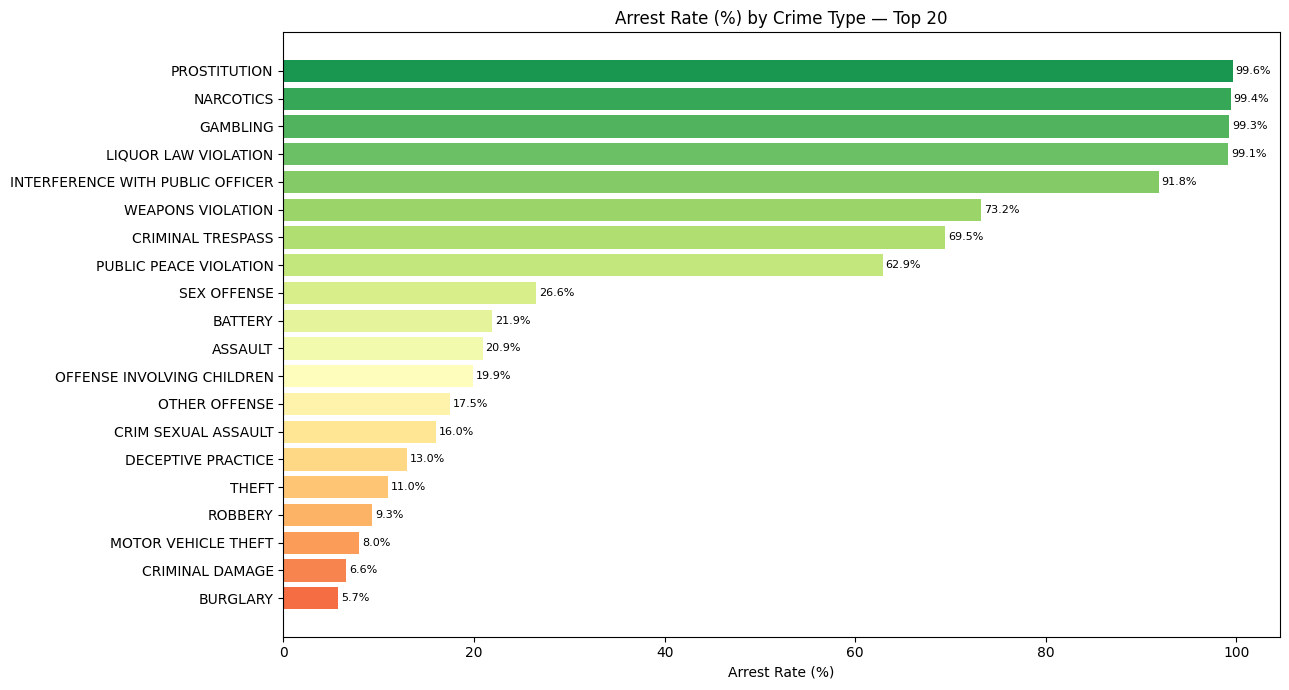

Saved: saved_charts\04_arrest_rate_by_crime_type_top20.png


In [9]:
top20_types = df['Primary Type'].value_counts().head(20).index
arrest_by_type = df[df['Primary Type'].isin(top20_types)].groupby('Primary Type').agg(total=('ID', 'count'), arrests=('Arrest', 'sum'))
arrest_by_type['arrest_rate'] = (arrest_by_type['arrests'] / arrest_by_type['total'] * 100)
arrest_by_type = arrest_by_type.sort_values('arrest_rate', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(arrest_by_type)))
bars = ax.barh(arrest_by_type.index[::-1], arrest_by_type['arrest_rate'][::-1], color=colors)
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate (%) by Crime Type — Top 20')

for bar, value in zip(bars, arrest_by_type['arrest_rate'][::-1]):
    ax.text(value + 0.3, bar.get_y() + bar.get_height() / 2, format(value, '.1f') + '%', va='center', fontsize=8)

plt.tight_layout()

save("arrest_rate_by_crime_type_top20")

# 5. Domestivs vs Non Domestic

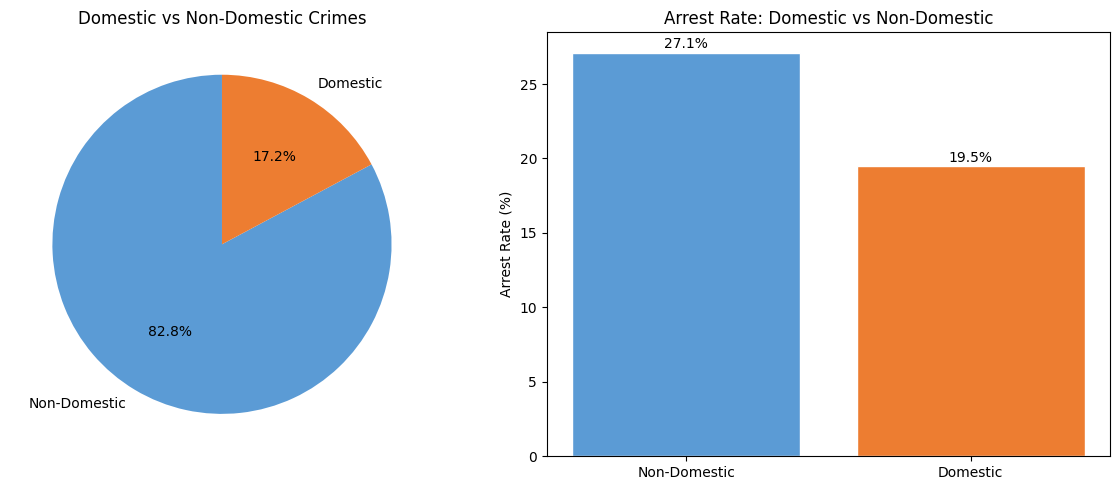

Saved: saved_charts\05_domestic_vs_nondomestic.png


In [10]:
dom = df.groupby('Domestic').agg(total=('ID', 'count'), arrests=('Arrest', 'sum'))
dom['arrest_rate'] = (dom['arrests'] / dom['total'] * 100)
dom.index = ['Non-Domestic', 'Domestic']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(dom['total'], labels=dom.index, autopct='%1.1f%%', colors=['#5b9bd5', '#ed7d31'], startangle=90)
axes[0].set_title('Domestic vs Non-Domestic Crimes')

axes[1].bar(dom.index, dom['arrest_rate'], color=['#5b9bd5', '#ed7d31'], edgecolor='white')
axes[1].set_title('Arrest Rate: Domestic vs Non-Domestic')
axes[1].set_ylabel('Arrest Rate (%)')

for i, row in enumerate(dom.itertuples()):
    axes[1].text(i, row.arrest_rate + 0.3, format(row.arrest_rate, '.1f') + '%', ha='center')

plt.tight_layout()

save("domestic_vs_nondomestic")

# 6. Temporal Patterns 

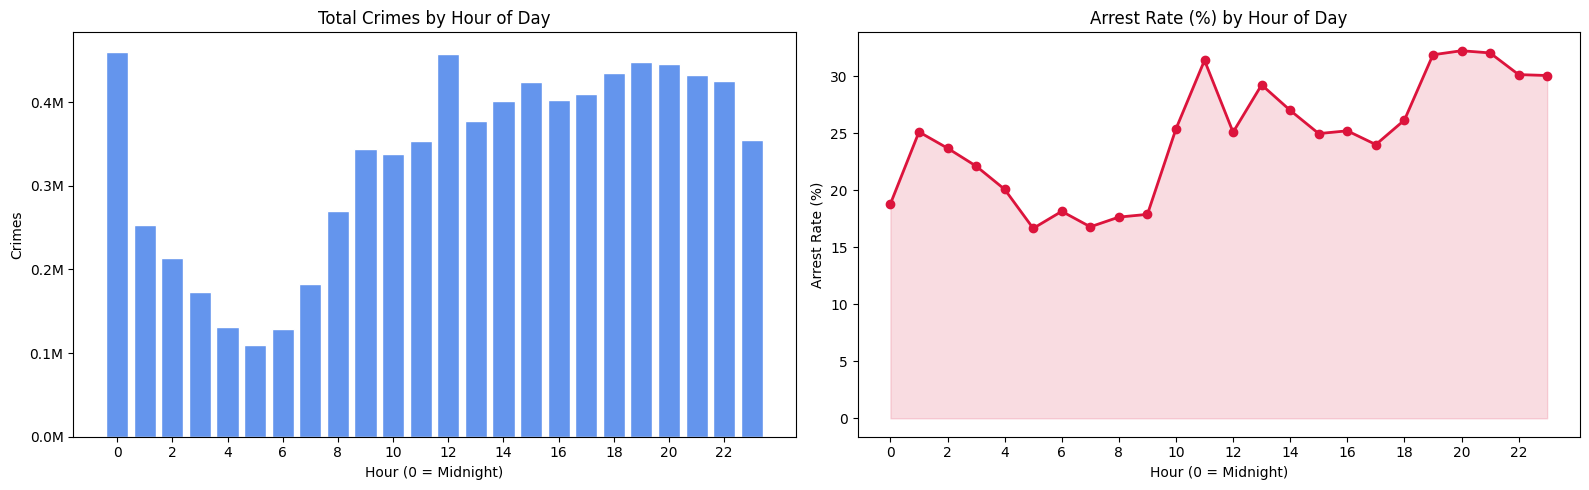

Saved: saved_charts\06_crimes_and_arrest_rate_by_hour.png


In [11]:
hourly = df.groupby('hour').agg(total_crimes=('ID', 'count'), total_arrests=('Arrest', 'sum'))
hourly['arrest_rate'] = (hourly['total_arrests'] / hourly['total_crimes'] * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(hourly.index, hourly['total_crimes'], color='cornflowerblue', edgecolor='white')
axes[0].set_title('Total Crimes by Hour of Day')
axes[0].set_xlabel('Hour (0 = Midnight)')
axes[0].set_ylabel('Crimes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
axes[0].set_xticks(range(0, 24, 2))

axes[1].plot(hourly.index, hourly['arrest_rate'], marker='o', color='crimson', linewidth=2)
axes[1].fill_between(hourly.index, hourly['arrest_rate'], color='crimson', alpha=0.15)
axes[1].set_title('Arrest Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour (0 = Midnight)')
axes[1].set_ylabel('Arrest Rate (%)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()

save("crimes_and_arrest_rate_by_hour")

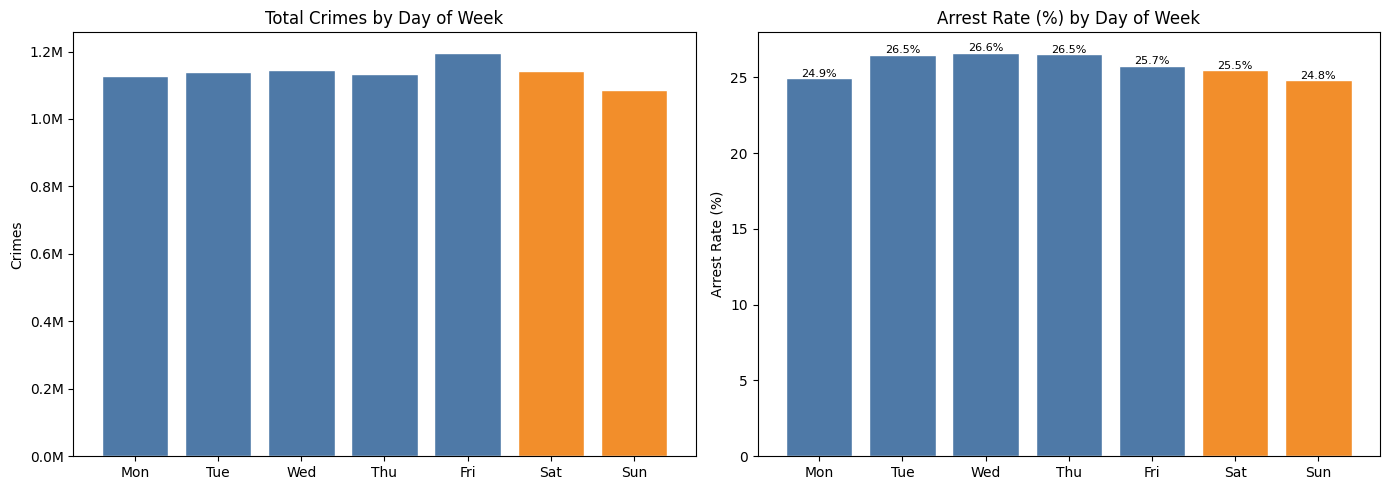

Saved: saved_charts\07_crimes_and_arrest_rate_by_day_of_week.png


In [12]:
dow = df.groupby('day_of_week').agg(total_crimes=('ID', 'count'), total_arrests=('Arrest', 'sum'))
dow['arrest_rate'] = (dow['total_arrests'] / dow['total_crimes'] * 100)
colors_dow = ['#4e79a7', '#4e79a7', '#4e79a7', '#4e79a7', '#4e79a7', '#f28e2b', '#f28e2b']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(day_labels, dow['total_crimes'], color=colors_dow, edgecolor='white')
axes[0].set_title('Total Crimes by Day of Week')
axes[0].set_ylabel('Crimes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
axes[1].bar(day_labels, dow['arrest_rate'], color=colors_dow, edgecolor='white')
axes[1].set_title('Arrest Rate (%) by Day of Week')
axes[1].set_ylabel('Arrest Rate (%)')

for i, value in enumerate(dow['arrest_rate']):
    axes[1].text(i, value + 0.1, format(value, '.1f') + '%', ha='center', fontsize=8)

plt.tight_layout()

save("crimes_and_arrest_rate_by_day_of_week")

# 7. Community Area

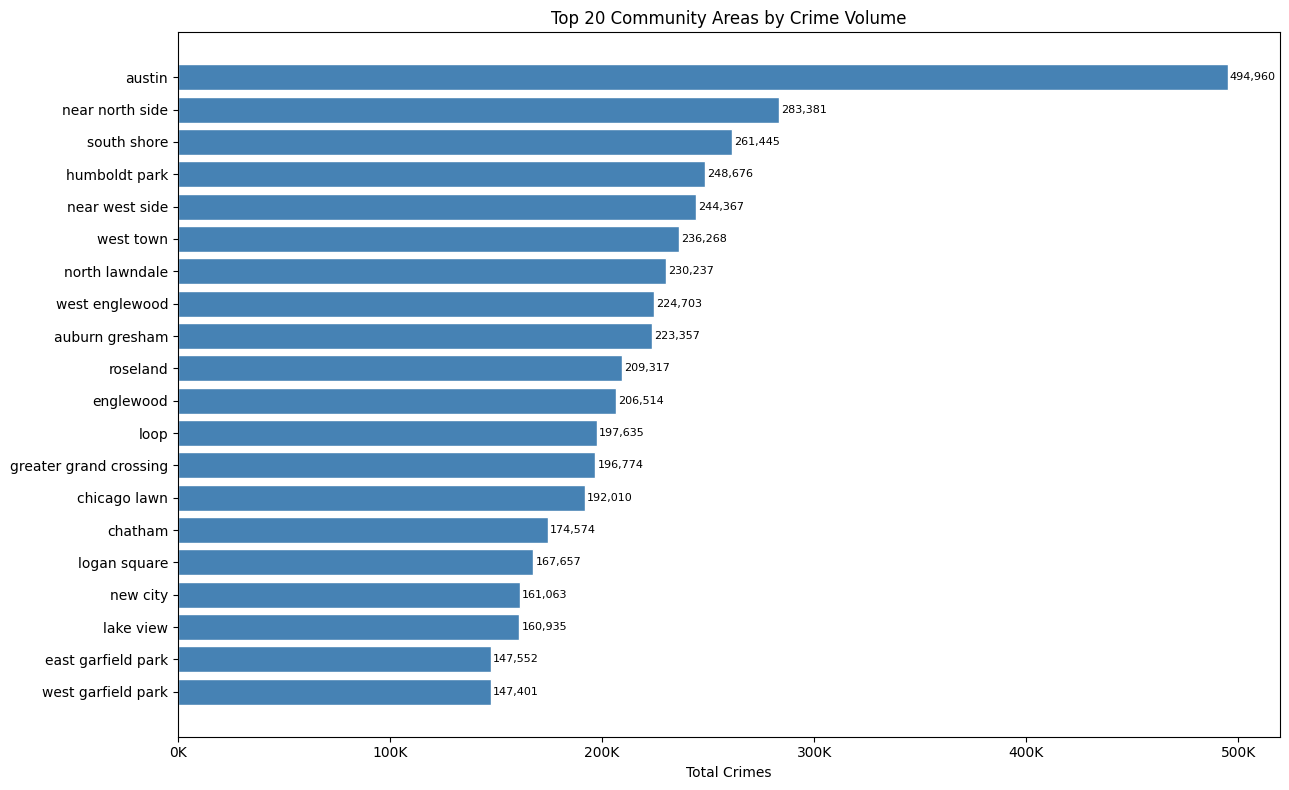

Saved: saved_charts\08_top20_community_areas_by_crime_volume.png


In [13]:
comm = df.groupby(['community_area', 'community_name']).agg(total_crimes=('ID', 'count'), total_arrests=('Arrest', 'sum')).reset_index()
comm['arrest_rate'] = (comm['total_arrests'] / comm['total_crimes'] * 100).round(2)
comm = comm.sort_values('total_crimes', ascending=False)
top20_comm = comm.head(20)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(top20_comm['community_name'][::-1], top20_comm['total_crimes'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Total Crimes')
ax.set_title('Top 20 Community Areas by Crime Volume')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e3:.0f}K'))

for bar, value in zip(bars, top20_comm['total_crimes'][::-1]):
    ax.text(value + 1000, bar.get_y() + bar.get_height() / 2, format(value, ','), va='center', fontsize=8)

plt.tight_layout()

save("top20_community_areas_by_crime_volume")

# Top Community by Arrest Rate

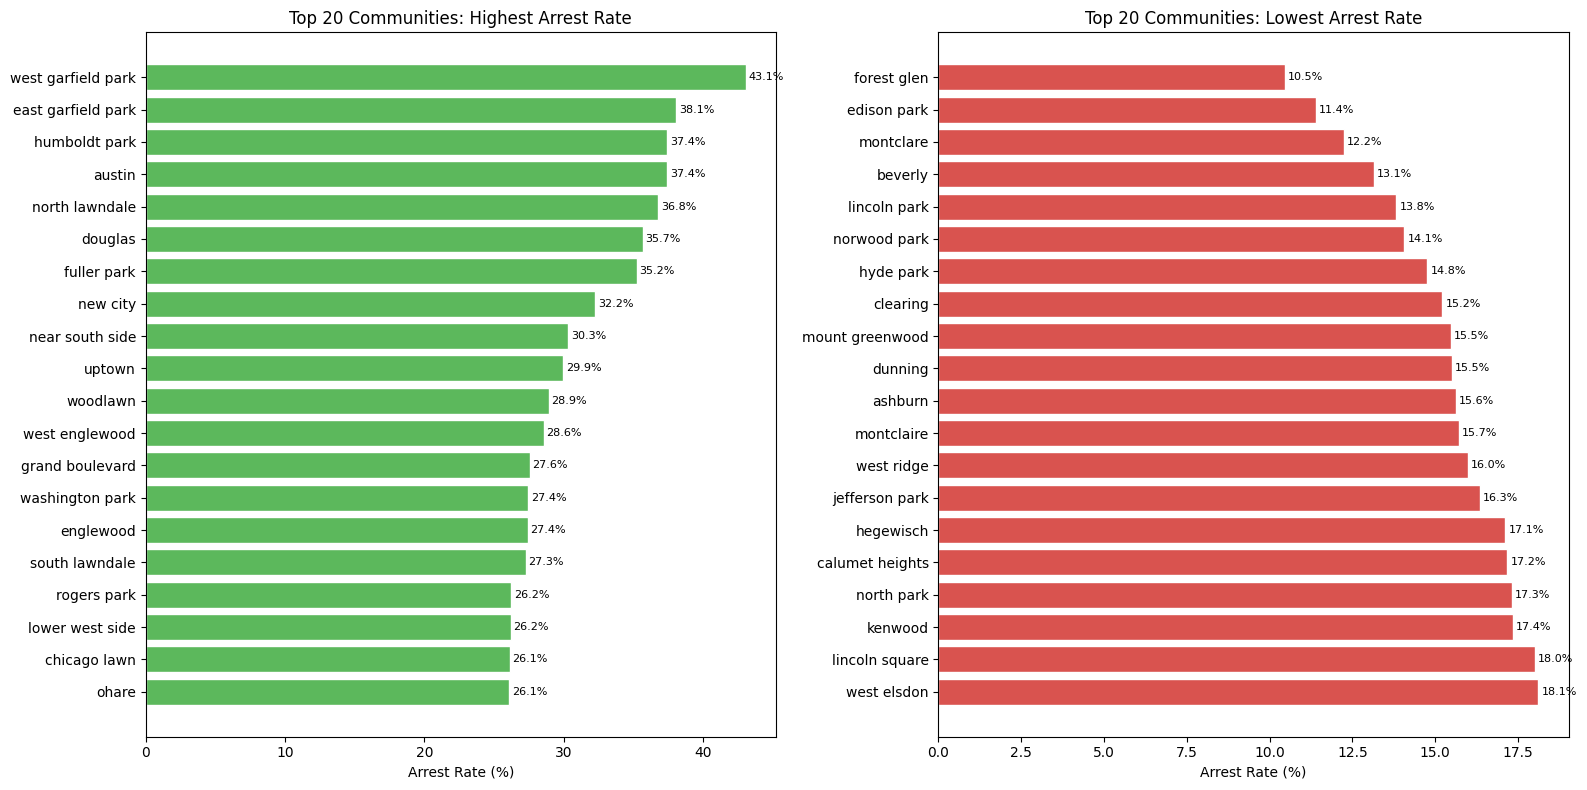

Saved: saved_charts\09_community_areas_highest_lowest_arrest_rate.png


In [14]:
comm_filtered = comm[comm['total_crimes'] >= 1000]
top20_ar = comm_filtered.sort_values('arrest_rate', ascending=False).head(20)
bot20_ar = comm_filtered.sort_values('arrest_rate').head(20)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(top20_ar['community_name'][::-1], top20_ar['arrest_rate'][::-1], color='#5cb85c', edgecolor='white')
axes[0].set_title('Top 20 Communities: Highest Arrest Rate')
axes[0].set_xlabel('Arrest Rate (%)')

for i, value in enumerate(top20_ar['arrest_rate'][::-1]):
    axes[0].text(value + 0.2, i, format(value, '.1f') + '%', va='center', fontsize=8)

axes[1].barh(bot20_ar['community_name'][::-1], bot20_ar['arrest_rate'][::-1], color='#d9534f', edgecolor='white')
axes[1].set_title('Top 20 Communities: Lowest Arrest Rate')
axes[1].set_xlabel('Arrest Rate (%)')

for i, value in enumerate(bot20_ar['arrest_rate'][::-1]):
    axes[1].text(value + 0.1, i, format(value, '.1f') + '%', va='center', fontsize=8)

plt.tight_layout()

save("community_areas_highest_lowest_arrest_rate")

# 8. Top 6 Crime Types for 5 community area

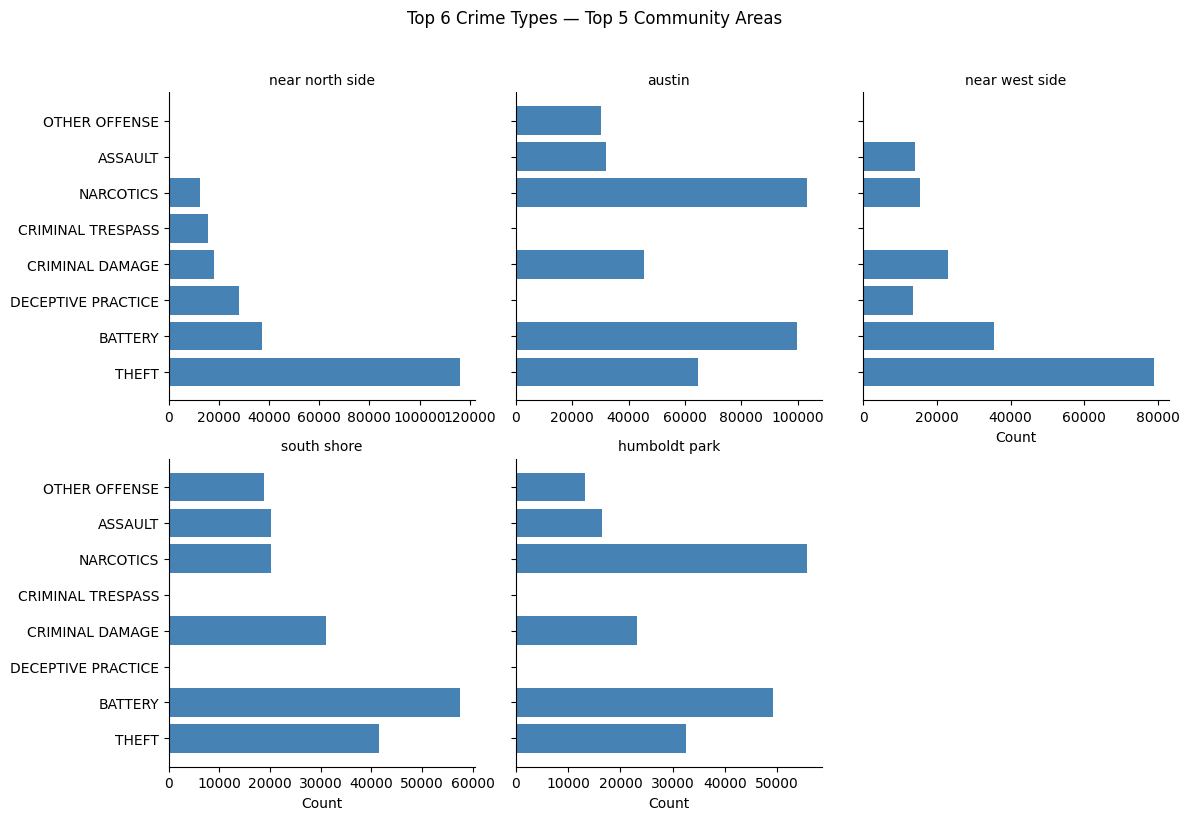

Saved: saved_charts\10_top6_crime_types_top5_communities.png


In [15]:
top5_comm_names = comm.head(5)['community_name'].tolist()
crime_comm_type = df[df['community_name'].isin(top5_comm_names)].groupby(['community_name', 'Primary Type'])['ID'].count().reset_index()
top6 = crime_comm_type.sort_values('ID', ascending=False).groupby('community_name').head(6)

g = sns.FacetGrid(top6, col='community_name', col_wrap=3, height=4, sharex=False)
g.map_dataframe(lambda data, **kwargs: plt.barh(data['Primary Type'], data['ID'], color='steelblue'))
g.set_axis_labels('Count', '')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Top 6 Crime Types — Top 5 Community Areas', y=1.02)

plt.tight_layout()

save("top6_crime_types_top5_communities")

# 10. Socio-Economic vs Crime & Arrest

In [16]:
comm_socio = df.groupby('community_name').agg(
    total_crimes=('ID', 'count'),
    arrest_rate=('Arrest', 'mean'),
    per_capita_income=('per_capita_income', 'mean'),
    unemployment_rate=('unemployment_rate', 'mean'),
    no_highschool_pct=('no_highschool_pct', 'mean')
).reset_index()

comm_socio['arrest_rate'] = (
    comm_socio['arrest_rate'] * 100
)

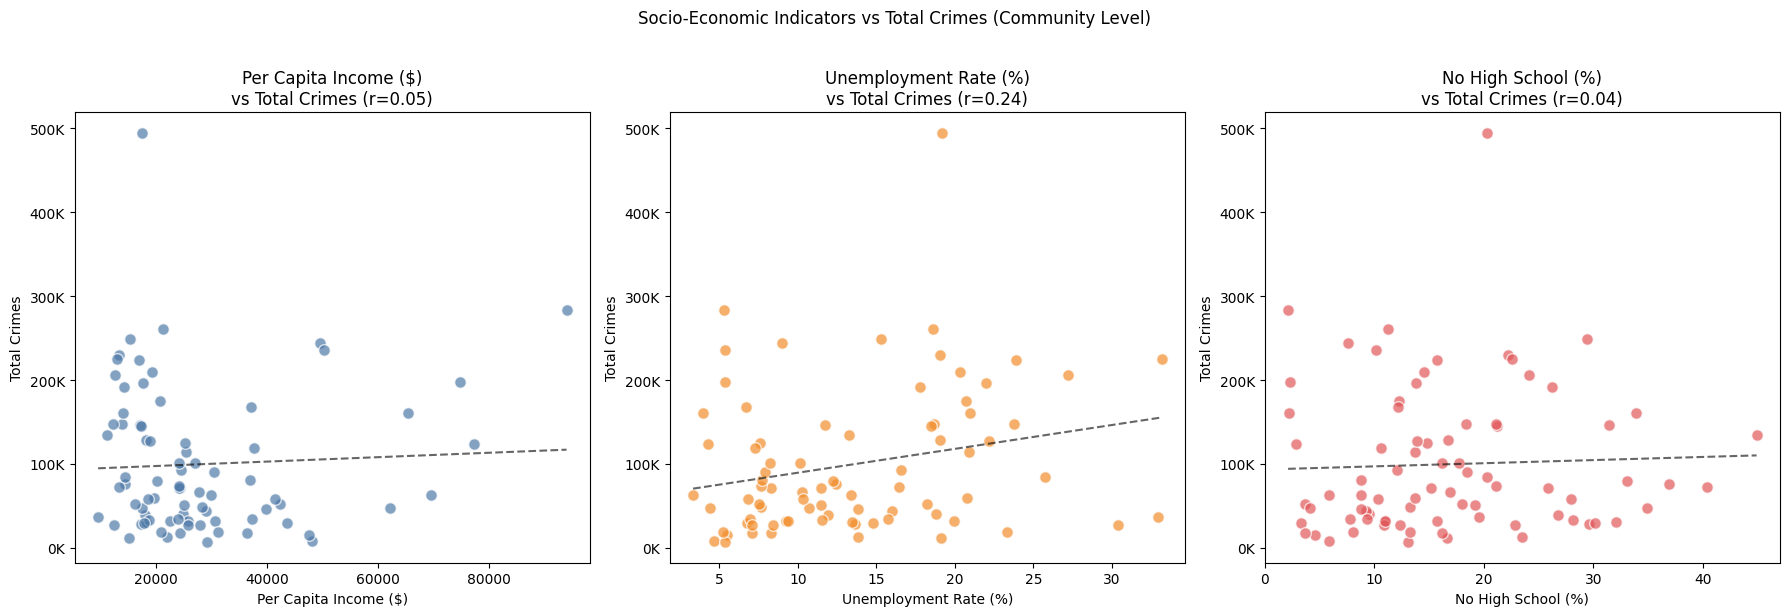

Saved: saved_charts\11_socioeconomic_vs_total_crimes.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scatter_pairs = [
    ('per_capita_income', 'total_crimes', 'Per Capita Income ($)', 'Total Crimes', '#4e79a7'),
    ('unemployment_rate', 'total_crimes', 'Unemployment Rate (%)', 'Total Crimes', '#f28e2b'),
    ('no_highschool_pct', 'total_crimes', 'No High School (%)', 'Total Crimes', '#e15759')
]

for ax, values in zip(axes, scatter_pairs):
    x = values[0]
    y = values[1]
    x_label = values[2]
    y_label = values[3]
    color = values[4]

    ax.scatter(comm_socio[x], comm_socio[y], color=color, alpha=0.7, edgecolors='white', s=70)
    z = np.polyfit(comm_socio[x], comm_socio[y], 1)
    xs = np.linspace(comm_socio[x].min(), comm_socio[x].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=1.5, alpha=0.6)

    corr = comm_socio[[x, y]].corr().iloc[0, 1]
    ax.set_title(x_label + '\nvs Total Crimes (r=' + format(corr, '.2f') + ')')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f'{v/1e3:.0f}K'))

plt.suptitle('Socio-Economic Indicators vs Total Crimes (Community Level)', y=1.02)
plt.tight_layout()

save("socioeconomic_vs_total_crimes")

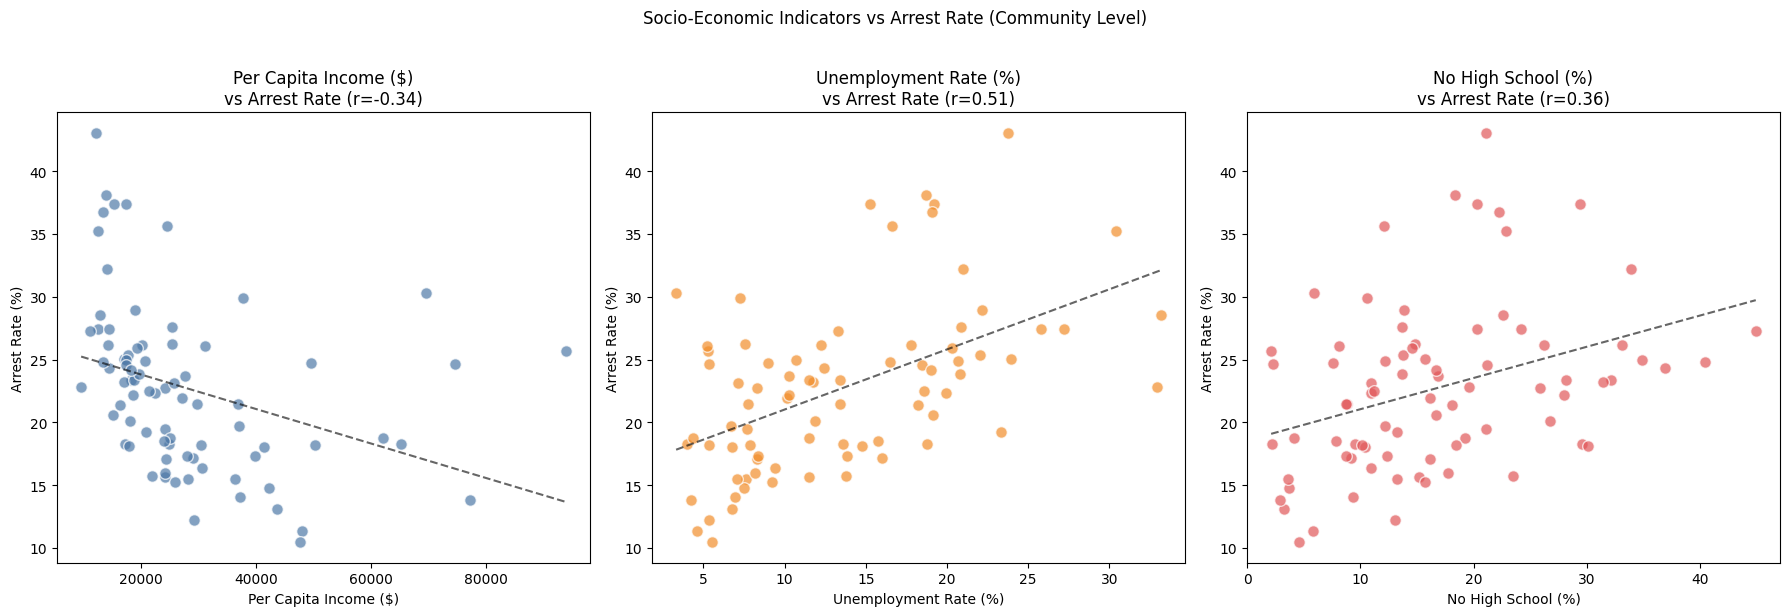

Saved: saved_charts\12_socioeconomic_vs_arrest_rate.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scatter_pairs2 = [
    ('per_capita_income', 'arrest_rate', 'Per Capita Income ($)', 'Arrest Rate (%)', '#4e79a7'),
    ('unemployment_rate', 'arrest_rate', 'Unemployment Rate (%)', 'Arrest Rate (%)', '#f28e2b'),
    ('no_highschool_pct', 'arrest_rate', 'No High School (%)', 'Arrest Rate (%)', '#e15759')
]

for ax, values in zip(axes, scatter_pairs2):
    x = values[0]
    y = values[1]
    x_label = values[2]
    y_label = values[3]
    color = values[4]

    ax.scatter(comm_socio[x], comm_socio[y], color=color, alpha=0.7, edgecolors='white', s=70)
    z = np.polyfit(comm_socio[x], comm_socio[y], 1)
    xs = np.linspace(comm_socio[x].min(), comm_socio[x].max(), 100)

    ax.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=1.5, alpha=0.6)
    corr = comm_socio[[x, y]].corr().iloc[0, 1]
    ax.set_title(x_label + '\nvs Arrest Rate (r=' + format(corr, '.2f') + ')')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

plt.suptitle('Socio-Economic Indicators vs Arrest Rate (Community Level)', y=1.02)
plt.tight_layout()

save("socioeconomic_vs_arrest_rate")

# 11. Arrest Rate by income & Unemployment Quintile

C:\Users\devan\AppData\Local\Temp\ipykernel_3904\1061139612.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_arrest = df.groupby('income_quintile')['Arrest'].mean() * 100
C:\Users\devan\AppData\Local\Temp\ipykernel_3904\1061139612.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qu_arrest = df.groupby('unemployment_quintile')['Arrest'].mean() * 100


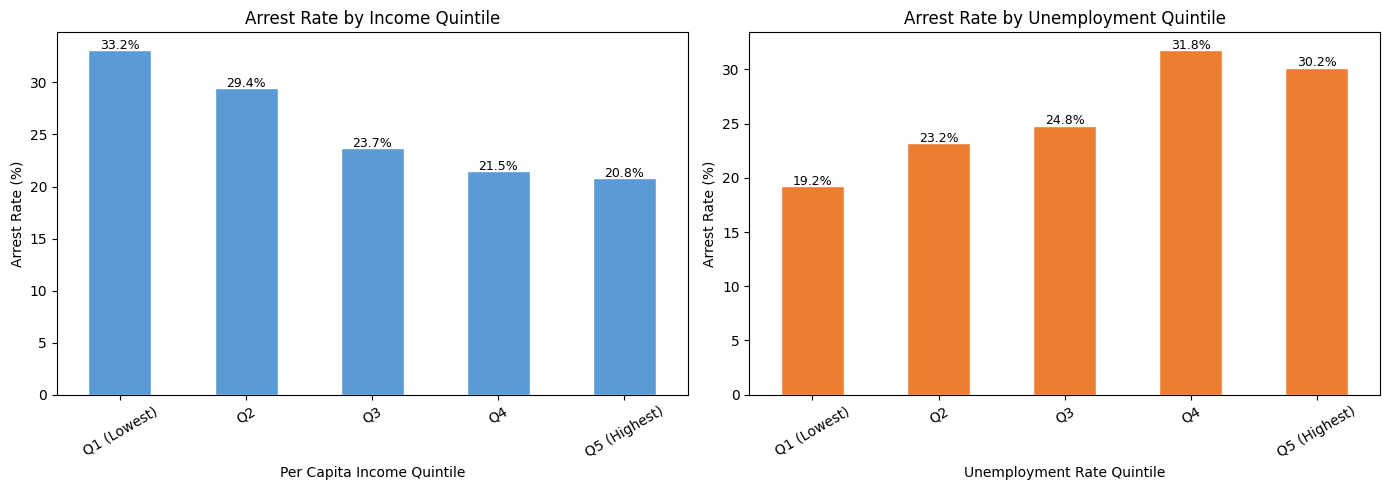

Saved: saved_charts\13_arrest_rate_by_income_and_unemployment_quintile.png


In [19]:
df['income_quintile'] = pd.qcut(df['per_capita_income'], q=5, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])
df['unemployment_quintile'] = pd.qcut(df['unemployment_rate'], q=5, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])

q_arrest = df.groupby('income_quintile')['Arrest'].mean() * 100
qu_arrest = df.groupby('unemployment_quintile')['Arrest'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
q_arrest.plot(kind='bar', ax=axes[0], color='#5b9bd5', edgecolor='white', rot=30)
axes[0].set_title('Arrest Rate by Income Quintile')
axes[0].set_ylabel('Arrest Rate (%)')
axes[0].set_xlabel('Per Capita Income Quintile')

for i, value in enumerate(q_arrest):
    axes[0].text(i, value + 0.1, format(value, '.1f') + '%', ha='center', fontsize=9)

qu_arrest.plot(kind='bar', ax=axes[1], color='#ed7d31', edgecolor='white', rot=30)
axes[1].set_title('Arrest Rate by Unemployment Quintile')
axes[1].set_ylabel('Arrest Rate (%)')
axes[1].set_xlabel('Unemployment Rate Quintile')

for i, value in enumerate(qu_arrest):
    axes[1].text(i, value + 0.1, format(value, '.1f') + '%', ha='center', fontsize=9)

plt.tight_layout()

save("arrest_rate_by_income_and_unemployment_quintile")

# 12. Weather Vs Crime

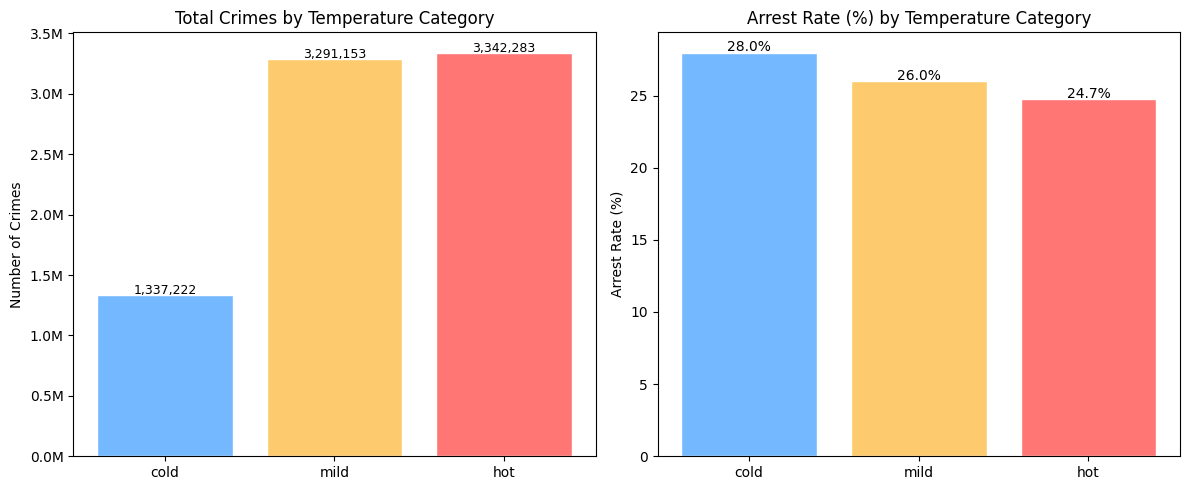

Saved: saved_charts\14_crimes_and_arrest_rate_by_temperature_category.png


In [20]:
temp_cat_order = ['cold', 'mild', 'hot']

temp_grp = df.groupby('temp_category').agg(total=('ID', 'count'), arrests=('Arrest', 'sum'))
temp_grp = temp_grp.reindex(temp_cat_order)
temp_grp['arrest_rate'] = (temp_grp['arrests'] / temp_grp['total'] * 100).round(2)
temp_colors = ['#74b9ff', '#fdcb6e', '#ff7675']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(temp_cat_order, temp_grp['total'], color=temp_colors, edgecolor='white')
axes[0].set_title('Total Crimes by Temperature Category')
axes[0].set_ylabel('Number of Crimes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

for i, value in enumerate(temp_grp['total']):
    axes[0].text(i, value + 2000, format(value, ','), ha='center', fontsize=9)

axes[1].bar(temp_cat_order, temp_grp['arrest_rate'], color=temp_colors, edgecolor='white')
axes[1].set_title('Arrest Rate (%) by Temperature Category')
axes[1].set_ylabel('Arrest Rate (%)')

for i, value in enumerate(temp_grp['arrest_rate']):
    axes[1].text(i, value + 0.1, format(value, '.1f') + '%', ha='center')

plt.tight_layout()

save("crimes_and_arrest_rate_by_temperature_category")

# 13. Rain / Snow Impact 

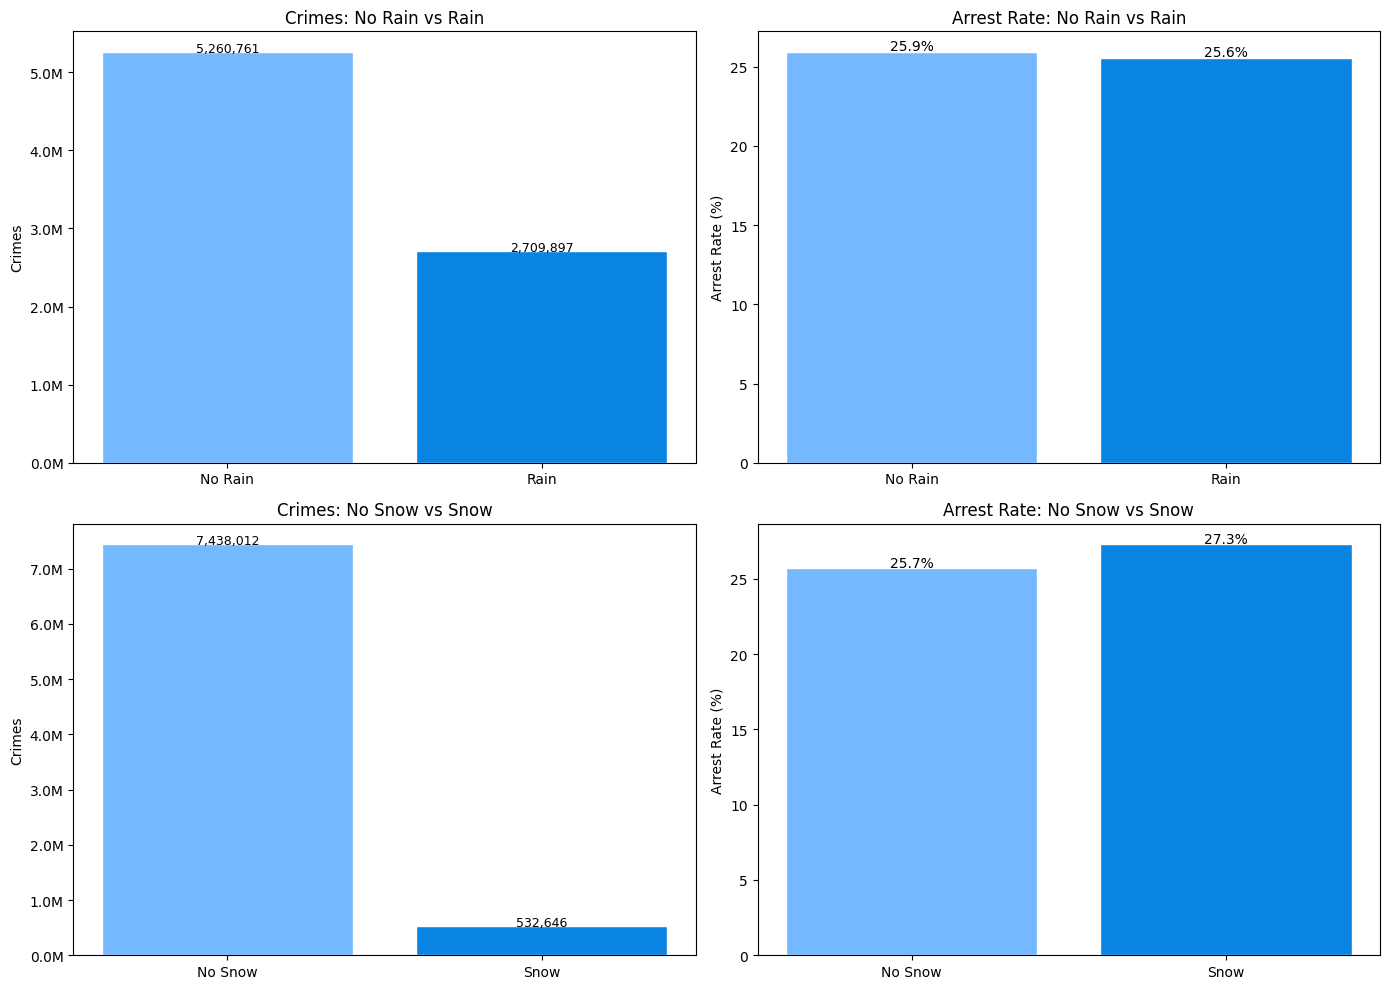

Saved: saved_charts\15_crimes_by_rain_and_snow.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

weather_flags = [('is_rain', ['No Rain', 'Rain']),('is_snow', ['No Snow', 'Snow'])]

for row_idx, values in enumerate(weather_flags):

    flag_col = values[0]
    flag_labels = values[1]

    grp = df.groupby(flag_col).agg(total=('ID', 'count'), arrests=('Arrest', 'sum'))
    grp['arrest_rate'] = (grp['arrests'] / grp['total'] * 100).round(2)
    grp.index = flag_labels

    axes[row_idx][0].bar( grp.index, grp['total'], color=['#74b9ff', '#0984e3'],edgecolor='white')
    axes[row_idx][0].set_title('Crimes: ' + flag_labels[0] + ' vs ' + flag_labels[1])
    axes[row_idx][0].set_ylabel('Crimes')
    axes[row_idx][0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

    for i, value in enumerate(grp['total']):
        axes[row_idx][0].text(i, value + 1000, format(value, ','), ha='center',fontsize=9)

    axes[row_idx][1].bar( grp.index, grp['arrest_rate'], color=['#74b9ff', '#0984e3'],edgecolor='white')
    axes[row_idx][1].set_title('Arrest Rate: ' + flag_labels[0] + ' vs ' + flag_labels[1])
    axes[row_idx][1].set_ylabel('Arrest Rate (%)')

    for i, value in enumerate(grp['arrest_rate']):
        axes[row_idx][1].text( i,  value + 0.1,format(value, '.1f') + '%', ha='center')

plt.tight_layout()

save("crimes_by_rain_and_snow")

# Daily Weather

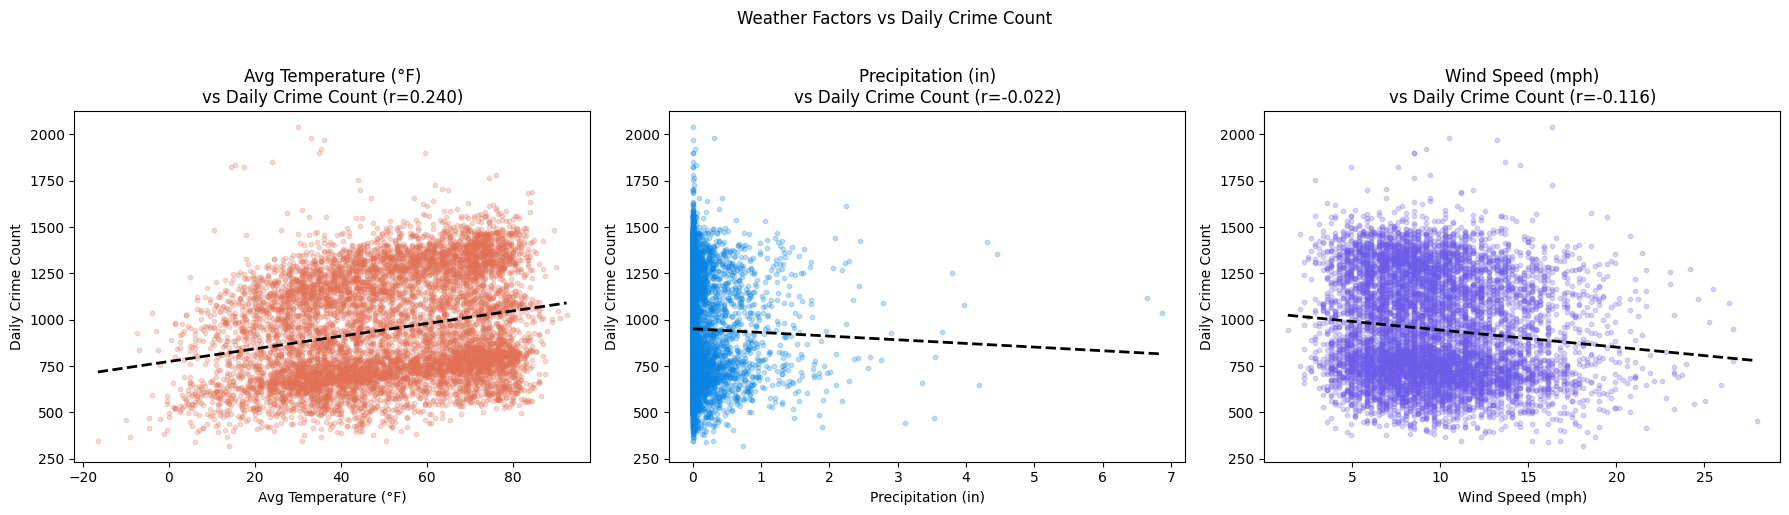

Saved: saved_charts\16_weather_factors_vs_daily_crime_count.png


In [22]:
daily = df.groupby('date').agg(crime_count=('ID', 'count'),arrest_rate=('Arrest', 'mean'), temp_avg=('temp_avg', 'first'), PRCP=('PRCP', 'first'),AWND=('AWND', 'first')).reset_index()

daily['arrest_rate'] = (daily['arrest_rate'] * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

weather_scatter = [
    (
        'temp_avg',
        'crime_count',
        'Avg Temperature (°F)',
        'Daily Crime Count',
        '#e17055'
    ),
    (
        'PRCP',
        'crime_count',
        'Precipitation (in)',
        'Daily Crime Count',
        '#0984e3'
    ),
    (
        'AWND',
        'crime_count',
        'Wind Speed (mph)',
        'Daily Crime Count',
        '#6c5ce7'
    )
]

for ax, values in zip(axes, weather_scatter):

    x = values[0]
    y = values[1]
    x_label = values[2]
    y_label = values[3]
    color = values[4]

    ax.scatter(daily[x],daily[y],alpha=0.25,s=10,color=color)
    z = np.polyfit(daily[x].dropna(),daily.loc[daily[x].notna(), y], 1)
    xs = np.linspace(daily[x].min(), daily[x].max(),100)
    ax.plot(xs, np.poly1d(z)(xs),'k--', linewidth=2)

    corr = daily[[x, y]].corr().iloc[0, 1]

    ax.set_title(x_label + '\nvs ' + y_label +' (r=' + format(corr, '.3f') + ')')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

plt.suptitle('Weather Factors vs Daily Crime Count', y=1.02)
plt.tight_layout()

save("weather_factors_vs_daily_crime_count")

# Arrest rate by crime type & Temperature

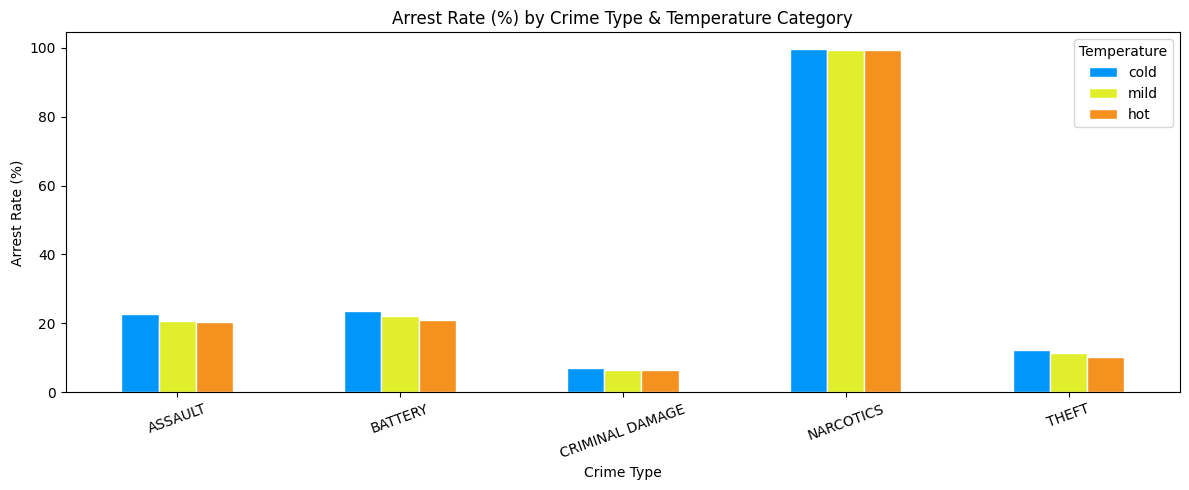

Saved: saved_charts\17_arrest_rate_by_crime_type_and_temperature.png


In [23]:
top5_types = ( df['Primary Type'].value_counts().head(5).index)

wt_ct = (df[df['Primary Type'].isin(top5_types)].groupby(['Primary Type', 'temp_category'])['Arrest'].mean() * 100)

wt_ct = wt_ct.unstack()
wt_ct = wt_ct.reindex(columns=['cold', 'mild', 'hot'])

wt_ct.plot(
    kind='bar',
    figsize=(12, 5),
    color=["#0096fa", "#e1ee2c", "#f5911e"],
    edgecolor='white',
    rot=20
)

plt.title('Arrest Rate (%) by Crime Type & Temperature Category')
plt.ylabel('Arrest Rate (%)')
plt.xlabel('Crime Type')
plt.legend(title='Temperature')
plt.tight_layout()

save("arrest_rate_by_crime_type_and_temperature")

# Correlation Heatmap

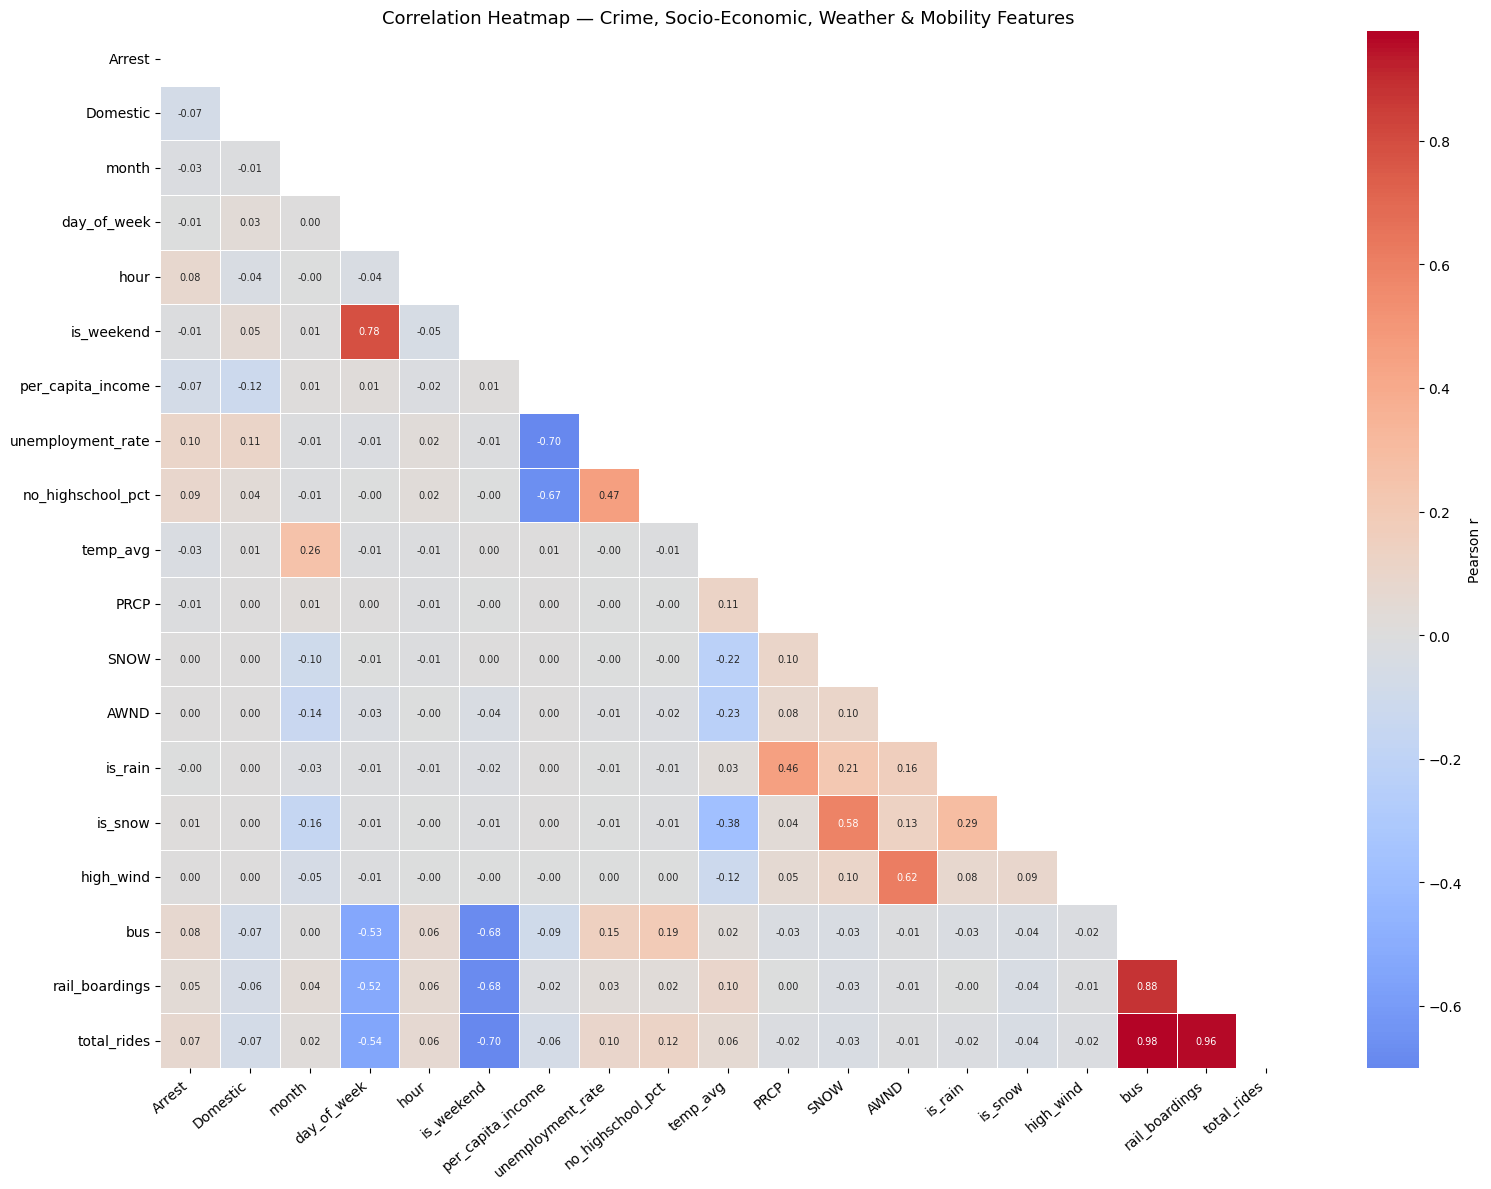

Saved: saved_charts\18_correlation_heatmap_all_features.png


In [24]:
corr_cols = [
    'Arrest','Domestic','month','day_of_week','hour','is_weekend',
    'per_capita_income','unemployment_rate','no_highschool_pct',
    'temp_avg','PRCP','SNOW','AWND','is_rain','is_snow','high_wind',
    'bus','rail_boardings','total_rides'
]

corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    linewidths=0.4,
    cbar_kws={'label': 'Pearson r'},
    annot_kws={'size': 7}
)

plt.title('Correlation Heatmap — Crime, Socio-Economic, Weather & Mobility Features', fontsize=13)
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

save('correlation_heatmap_all_features')


# 14. Mobility Overview — Transit Ridership Trends

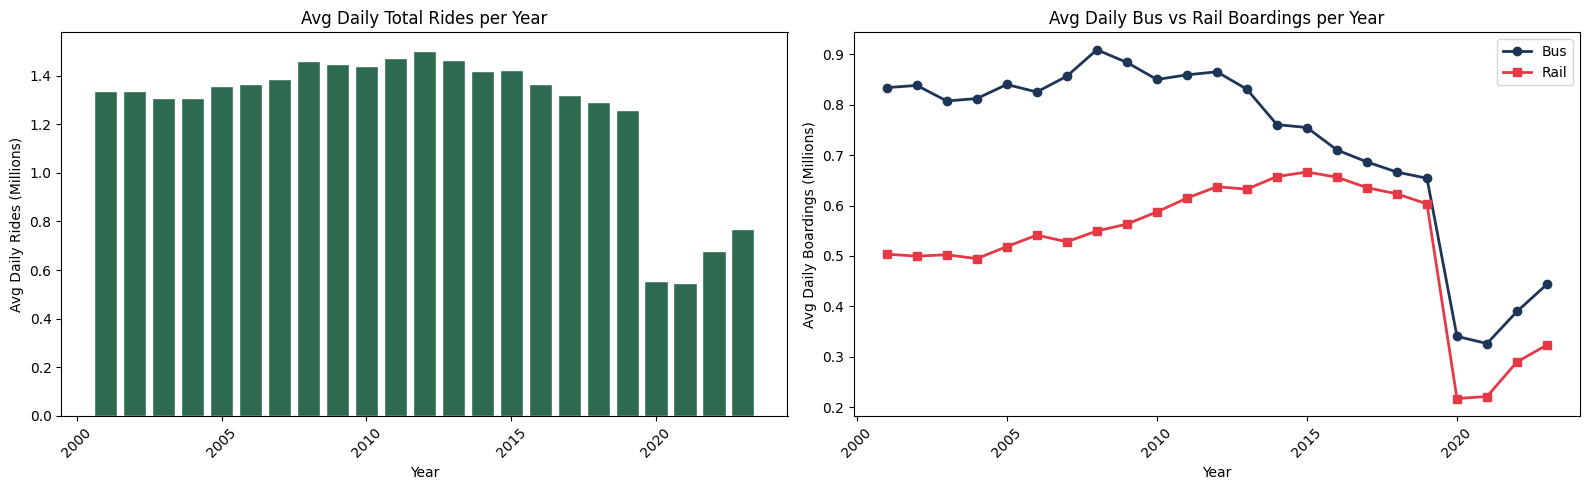

Saved: saved_charts\19_mobility_transit_trends_by_year.png


In [25]:
# Daily transit ridership aggregated by year
mob_yearly = df.groupby('year').agg(
    total_rides_sum=('total_rides', 'mean'),
    bus_mean=('bus', 'mean'),
    rail_mean=('rail_boardings', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(mob_yearly['year'], mob_yearly['total_rides_sum'] / 1e6,
            color='#2d6a4f', edgecolor='white')
axes[0].set_title('Avg Daily Total Rides per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Daily Rides (Millions)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(mob_yearly['year'], mob_yearly['bus_mean'] / 1e6,
             marker='o', color='#1d3557', linewidth=2, label='Bus')
axes[1].plot(mob_yearly['year'], mob_yearly['rail_mean'] / 1e6,
             marker='s', color='#e63946', linewidth=2, label='Rail')
axes[1].set_title('Avg Daily Bus vs Rail Boardings per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Daily Boardings (Millions)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
save('mobility_transit_trends_by_year')


# 15. Mobility — Day Type Analysis (Weekday / Saturday / Sunday-Holiday)

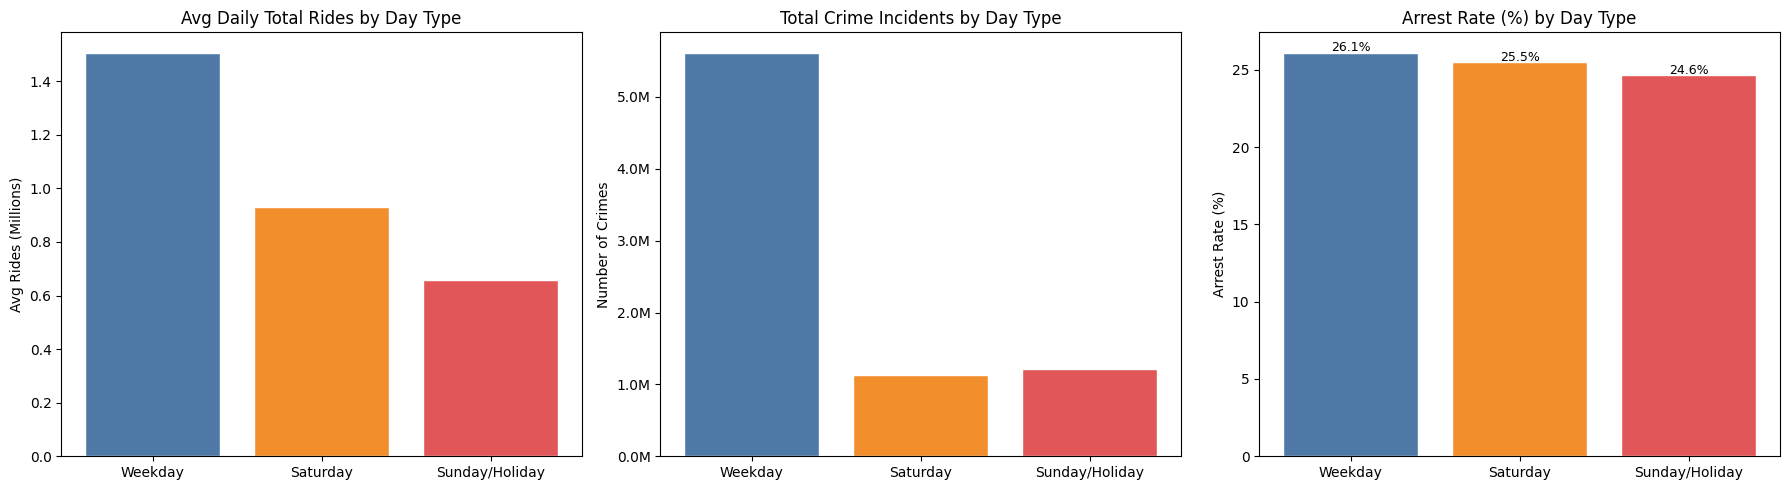

Saved: saved_charts\20_mobility_crime_by_day_type.png


In [26]:
# day_type: W=Weekday, A=Saturday, U=Sunday/Holiday
day_type_map = {'W': 'Weekday', 'A': 'Saturday', 'U': 'Sunday/Holiday'}
df['day_type_label'] = df['day_type'].map(day_type_map)

mob_daytype = df.groupby('day_type_label').agg(
    avg_total_rides=('total_rides', 'mean'),
    avg_bus=('bus', 'mean'),
    avg_rail=('rail_boardings', 'mean'),
    crime_count=('ID', 'count'),
    arrest_rate=('Arrest', 'mean')
).reset_index()
mob_daytype['arrest_rate'] = mob_daytype['arrest_rate'] * 100

order = ['Weekday', 'Saturday', 'Sunday/Holiday']
mob_daytype = mob_daytype.set_index('day_type_label').reindex(order).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4e79a7', '#f28e2b', '#e15759']

axes[0].bar(mob_daytype['day_type_label'], mob_daytype['avg_total_rides'] / 1e6,
            color=colors, edgecolor='white')
axes[0].set_title('Avg Daily Total Rides by Day Type')
axes[0].set_ylabel('Avg Rides (Millions)')

axes[1].bar(mob_daytype['day_type_label'], mob_daytype['crime_count'],
            color=colors, edgecolor='white')
axes[1].set_title('Total Crime Incidents by Day Type')
axes[1].set_ylabel('Number of Crimes')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

axes[2].bar(mob_daytype['day_type_label'], mob_daytype['arrest_rate'],
            color=colors, edgecolor='white')
axes[2].set_title('Arrest Rate (%) by Day Type')
axes[2].set_ylabel('Arrest Rate (%)')
for i, v in enumerate(mob_daytype['arrest_rate']):
    axes[2].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
save('mobility_crime_by_day_type')


# 16. Mobility vs Crime — Scatter Analysis

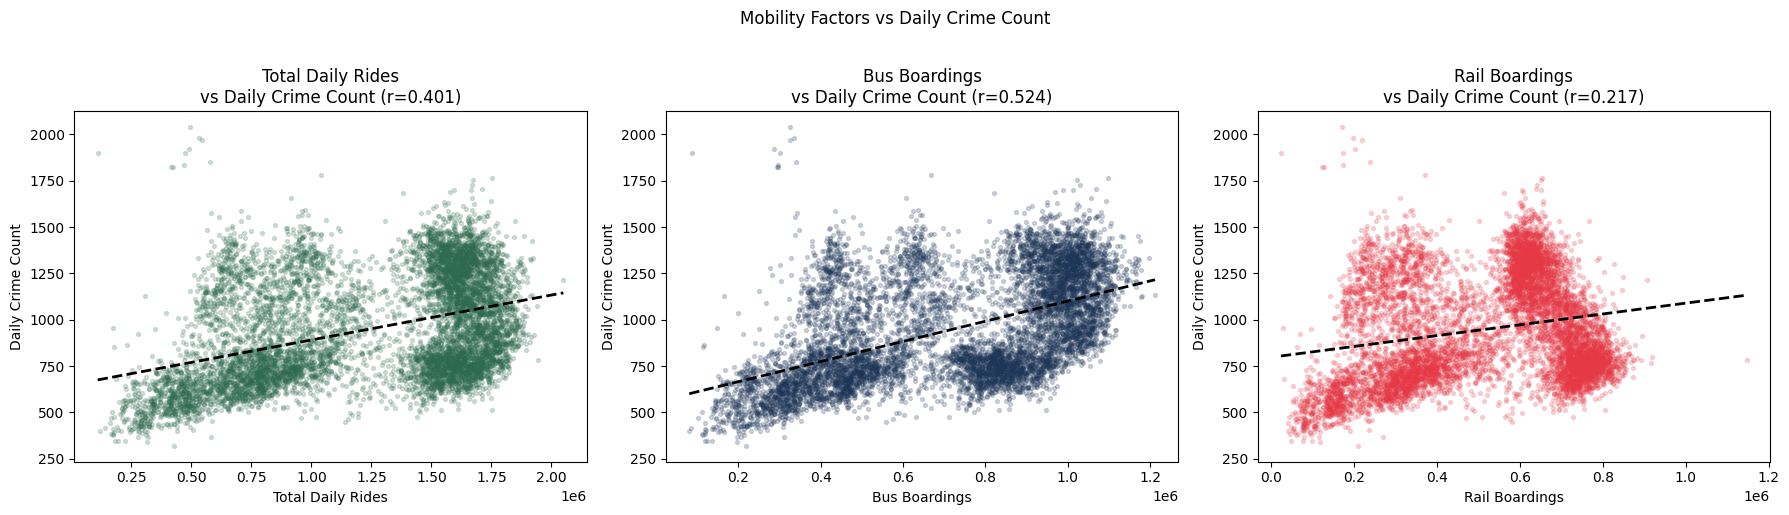

Saved: saved_charts\21_mobility_vs_daily_crime_count.png


In [27]:
daily_mob = df.groupby('date').agg(
    crime_count=('ID', 'count'),
    arrest_rate=('Arrest', 'mean'),
    total_rides=('total_rides', 'first'),
    bus=('bus', 'first'),
    rail_boardings=('rail_boardings', 'first')
).reset_index()
daily_mob['arrest_rate'] = daily_mob['arrest_rate'] * 100

mob_scatter = [
    ('total_rides', 'crime_count', 'Total Daily Rides', 'Daily Crime Count', '#2d6a4f'),
    ('bus',         'crime_count', 'Bus Boardings',     'Daily Crime Count', '#1d3557'),
    ('rail_boardings','crime_count','Rail Boardings',   'Daily Crime Count', '#e63946'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, y, x_label, y_label, color) in zip(axes, mob_scatter):
    data = daily_mob[[x, y]].dropna()
    ax.scatter(data[x], data[y], alpha=0.2, s=8, color=color)
    z = np.polyfit(data[x], data[y], 1)
    xs = np.linspace(data[x].min(), data[x].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=2)
    corr = data.corr().iloc[0, 1]
    ax.set_title(f'{x_label}\nvs {y_label} (r={corr:.3f})')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

plt.suptitle('Mobility Factors vs Daily Crime Count', y=1.02)
plt.tight_layout()
save('mobility_vs_daily_crime_count')


# 17. Mobility — Monthly Ridership Pattern

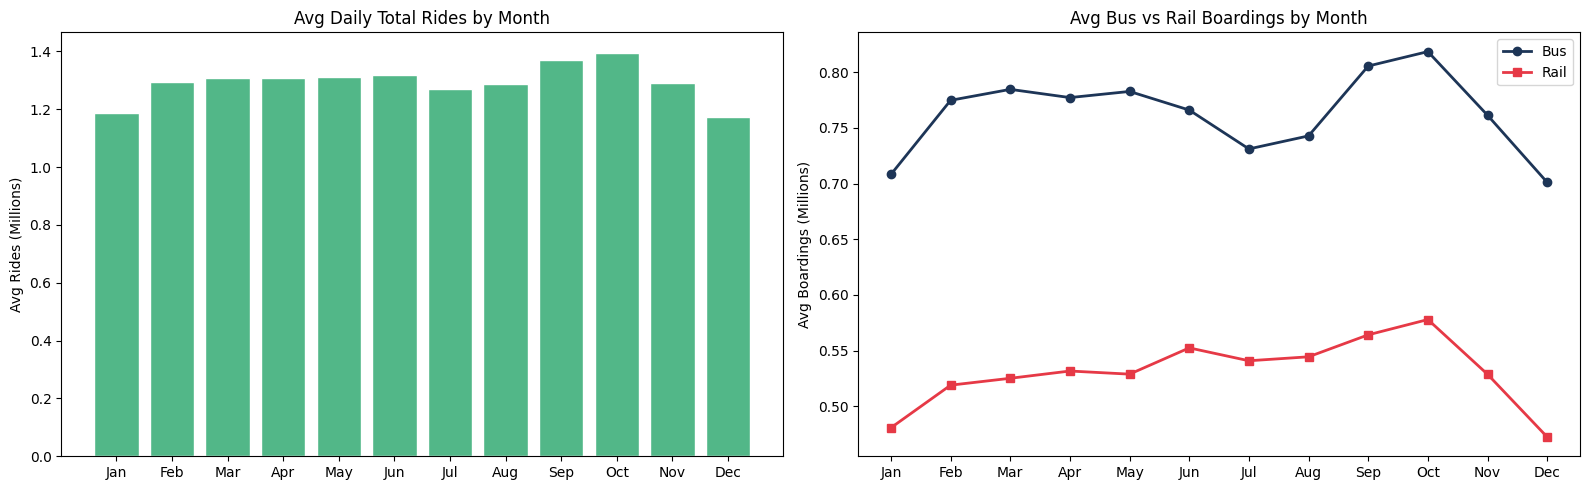

Saved: saved_charts\22_mobility_ridership_by_month.png


In [28]:
mob_monthly = df.groupby('month').agg(
    avg_total_rides=('total_rides', 'mean'),
    avg_bus=('bus', 'mean'),
    avg_rail=('rail_boardings', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(mob_monthly['month'], mob_monthly['avg_total_rides'] / 1e6,
            color='#52b788', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Avg Daily Total Rides by Month')
axes[0].set_ylabel('Avg Rides (Millions)')

axes[1].plot(mob_monthly['month'], mob_monthly['avg_bus'] / 1e6,
             marker='o', color='#1d3557', linewidth=2, label='Bus')
axes[1].plot(mob_monthly['month'], mob_monthly['avg_rail'] / 1e6,
             marker='s', color='#e63946', linewidth=2, label='Rail')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Avg Bus vs Rail Boardings by Month')
axes[1].set_ylabel('Avg Boardings (Millions)')
axes[1].legend()

plt.tight_layout()
save('mobility_ridership_by_month')


# 18. Mobility — Crime by Ridership Quartile

C:\Users\devan\AppData\Local\Temp\ipykernel_3904\678126113.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rides_q = df.groupby('rides_quartile').agg(


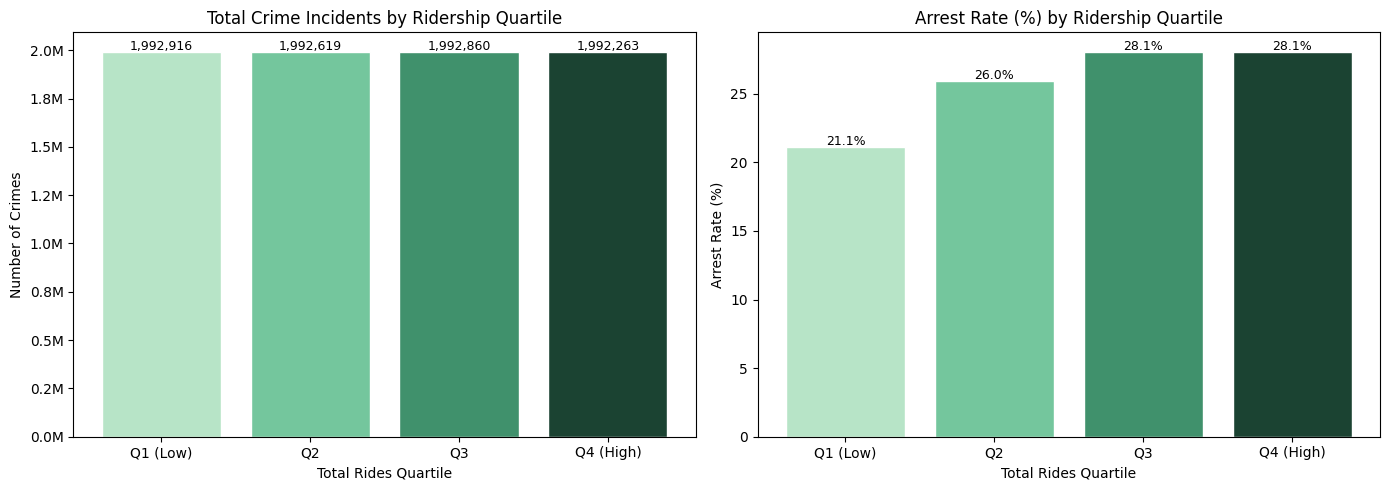

Saved: saved_charts\23_crime_and_arrest_by_ridership_quartile.png


In [29]:
df['rides_quartile'] = pd.qcut(
    df['total_rides'], q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)

rides_q = df.groupby('rides_quartile').agg(
    total_crimes=('ID', 'count'),
    arrest_rate=('Arrest', 'mean')
).reset_index()
rides_q['arrest_rate'] = rides_q['arrest_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_q = ['#b7e4c7', '#74c69d', '#40916c', '#1b4332']

axes[0].bar(rides_q['rides_quartile'], rides_q['total_crimes'],
            color=colors_q, edgecolor='white')
axes[0].set_title('Total Crime Incidents by Ridership Quartile')
axes[0].set_xlabel('Total Rides Quartile')
axes[0].set_ylabel('Number of Crimes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
for i, v in enumerate(rides_q['total_crimes']):
    axes[0].text(i, v + 10000, format(v, ','), ha='center', fontsize=9)

axes[1].bar(rides_q['rides_quartile'], rides_q['arrest_rate'],
            color=colors_q, edgecolor='white')
axes[1].set_title('Arrest Rate (%) by Ridership Quartile')
axes[1].set_xlabel('Total Rides Quartile')
axes[1].set_ylabel('Arrest Rate (%)')
for i, v in enumerate(rides_q['arrest_rate']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
save('crime_and_arrest_by_ridership_quartile')


# 19. Mobility — Top 5 Crime Types vs Ridership Level

C:\Users\devan\AppData\Local\Temp\ipykernel_3904\297683762.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Primary Type', 'rides_quartile'])['ID']


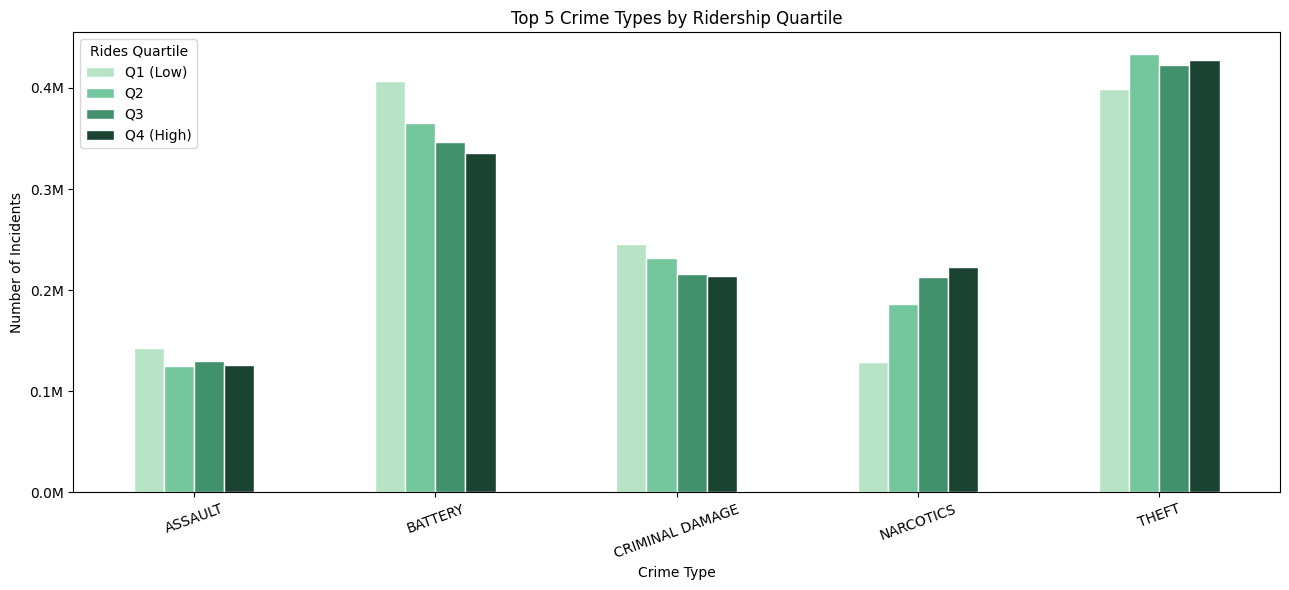

Saved: saved_charts\24_top5_crime_types_by_ridership_quartile.png


In [30]:
top5_types = df['Primary Type'].value_counts().head(5).index

mob_crime_type = (
    df[df['Primary Type'].isin(top5_types)]
    .groupby(['Primary Type', 'rides_quartile'])['ID']
    .count()
    .unstack()
)

mob_crime_type.plot(
    kind='bar',
    figsize=(13, 6),
    color=['#b7e4c7', '#74c69d', '#40916c', '#1b4332'],
    edgecolor='white',
    rot=20
)

plt.title('Top 5 Crime Types by Ridership Quartile')
plt.xlabel('Crime Type')
plt.ylabel('Number of Incidents')
plt.legend(title='Rides Quartile')
plt.yaxis = plt.gca().yaxis
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.tight_layout()
save('top5_crime_types_by_ridership_quartile')


# Overall


In [31]:
total = len(df)
arrest_pct = df['Arrest'].mean() * 100
peak_year = yearly.loc[yearly['total_crimes'].idxmax(), 'year']
min_year = yearly.loc[yearly['total_crimes'].idxmin(), 'year']
top_crime = df['Primary Type'].value_counts().idxmax()
highest_ar_crime = arrest_by_type['arrest_rate'].idxmax()
lowest_ar_crime = arrest_by_type['arrest_rate'].idxmin()
hottest_community = comm.iloc[0]['community_name']
peak_hour = hourly['total_crimes'].idxmax()
peak_dow = dow['total_crimes'].idxmax()

In [32]:
print('\nOVERVIEW')

print('Total crimes (2001–2023) :', format(total, ','))
print('Overall arrest rate :', format(arrest_pct, '.2f') + '%')


OVERVIEW
Total crimes (2001–2023) : 7,970,658
Overall arrest rate : 25.80%


In [33]:
print('\nTRENDS')

print('Peak crime year :', peak_year)
print('Lowest crime year :', min_year)
print('Peak crime month :', month_names[monthly['total_crimes'].idxmax() - 1])
print('Peak crime hour :', str(peak_hour) + ':00')
print('Peak crime day :', day_labels[peak_dow])


TRENDS
Peak crime year : 2001
Lowest crime year : 2021
Peak crime month : Jun
Peak crime hour : 0:00
Peak crime day : Fri


In [34]:
print('\nCRIME TYPES')

print('Most common crime :', top_crime)
print('Highest arrest rate crime :', highest_ar_crime)
print('Lowest arrest rate crime :', lowest_ar_crime)


CRIME TYPES
Most common crime : THEFT
Highest arrest rate crime : PROSTITUTION
Lowest arrest rate crime : BURGLARY


In [35]:
print('\nCOMMUNITY AREAS')
print('Highest crime community :', hottest_community)

high_ar_comm = comm_filtered.sort_values('arrest_rate', ascending=False).iloc[0]['community_name']
low_ar_comm = comm_filtered.sort_values('arrest_rate').iloc[0]['community_name']

print('Highest arrest rate community :', high_ar_comm)
print('Lowest arrest rate community :', low_ar_comm)


COMMUNITY AREAS
Highest crime community : austin
Highest arrest rate community : west garfield park
Lowest arrest rate community : forest glen


In [36]:
print('\nSOCIO-ECONOMIC')

q1_ar = df[df['income_quintile'] == 'Q1 (Lowest)']['Arrest'].mean() * 100
q5_ar = df[df['income_quintile'] == 'Q5 (Highest)']['Arrest'].mean() * 100

print('Arrest rate Q1 (lowest income) :', format(q1_ar, '.2f') + '%')
print('Arrest rate Q5 (highest income) :', format(q5_ar, '.2f') + '%')


SOCIO-ECONOMIC
Arrest rate Q1 (lowest income) : 33.16%
Arrest rate Q5 (highest income) : 20.80%


In [37]:
print('\nWEATHER')

hot_ar = df[df['temp_category'] == 'hot']['Arrest'].mean() * 100
cold_ar = df[df['temp_category'] == 'cold']['Arrest'].mean() * 100
rain_ar = df[df['is_rain'] == 1]['Arrest'].mean() * 100
no_rain_ar = df[df['is_rain'] == 0]['Arrest'].mean() * 100

print('Arrest rate (hot days) :', format(hot_ar, '.2f') + '%')
print('Arrest rate (cold days) :', format(cold_ar, '.2f') + '%')
print('Arrest rate (rainy days) :', format(rain_ar, '.2f') + '%')
print('Arrest rate (dry days) :', format(no_rain_ar, '.2f') + '%')



WEATHER
Arrest rate (hot days) : 24.73%
Arrest rate (cold days) : 27.98%
Arrest rate (rainy days) : 25.56%
Arrest rate (dry days) : 25.93%


In [38]:
print('\nMOBILITY')

peak_rides_month = mob_monthly['avg_total_rides'].idxmax() + 1
low_rides_month  = mob_monthly['avg_total_rides'].idxmin() + 1

q1_rides_ar = df[df['rides_quartile'] == 'Q1 (Low)']['Arrest'].mean() * 100
q4_rides_ar = df[df['rides_quartile'] == 'Q4 (High)']['Arrest'].mean() * 100

weekday_ar = df[df['day_type'] == 'W']['Arrest'].mean() * 100
weekend_ar = df[df['day_type'] == 'U']['Arrest'].mean() * 100

print('Peak ridership month       :', month_names[peak_rides_month - 1])
print('Lowest ridership month     :', month_names[low_rides_month - 1])
print('Arrest rate (low rides Q1) :', format(q1_rides_ar, '.2f') + '%')
print('Arrest rate (high rides Q4):', format(q4_rides_ar, '.2f') + '%')
print('Arrest rate (weekday)      :', format(weekday_ar, '.2f') + '%')
print('Arrest rate (Sunday/Hol.)  :', format(weekend_ar, '.2f') + '%')



MOBILITY
Peak ridership month       : Oct
Lowest ridership month     : Dec
Arrest rate (low rides Q1) : 21.14%
Arrest rate (high rides Q4): 28.06%
Arrest rate (weekday)      : 26.12%
Arrest rate (Sunday/Hol.)  : 24.64%


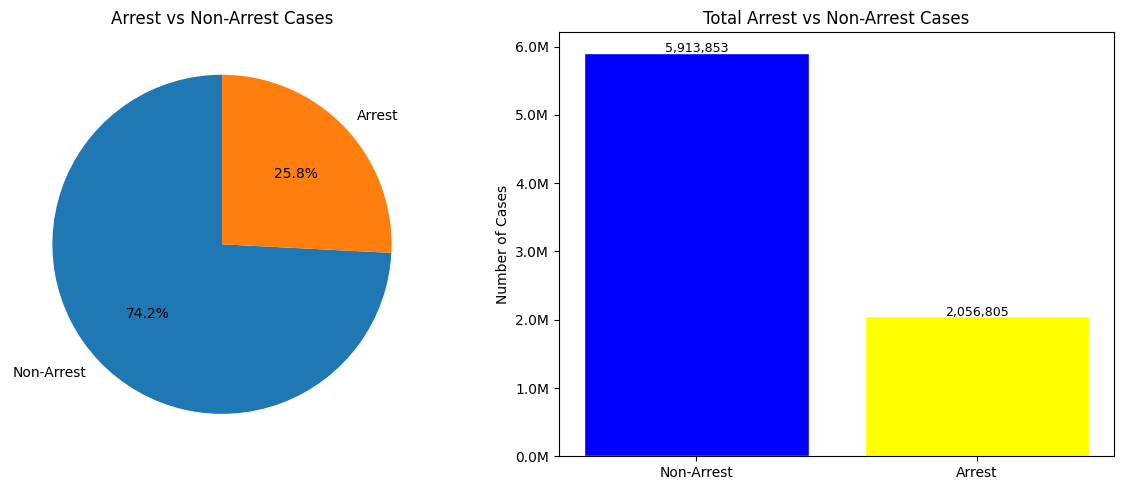

Saved: saved_charts\25_arrest_vs_non_arrest.png


In [39]:
arrest_status = df.groupby('Arrest').agg(total=('ID', 'count')).reset_index()

arrest_status['status'] = arrest_status['Arrest'].map({0: 'Non-Arrest', 1: 'Arrest'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    arrest_status['total'],
    labels=arrest_status['status'],
    autopct='%1.1f%%',

    startangle=90
)

axes[0].set_title('Arrest vs Non-Arrest Cases')

axes[1].bar(
    arrest_status['status'],
    arrest_status['total'],
    color=['blue', 'yellow'],
    edgecolor='white'
)

axes[1].set_title('Total Arrest vs Non-Arrest Cases')

axes[1].set_ylabel('Number of Cases')

axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

for i, value in enumerate(arrest_status['total']):
    axes[1].text(i, value + 5000, format(value, ','), ha='center', fontsize=9)

plt.tight_layout()

save("arrest_vs_non_arrest")